###1.데이터를 가져오기 위해 깃허브와 연동

###2.한글깨짐 방지를 위해 폰트 설정

###3.깃허브의 Data 불러오기  --> 데이터가 없을 시 다음 단계(4번) 실행해도 됨
###https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv  참고

###4.Seaborn의 penguins 데이터 불러오기  :Seaborn 패키지에 데이터 세트로 존재하는 파일 가져오기

###5.불러온 데이터에 대한 기본 정보 확인

###6. 각 columns 별로 결측치가 존재하는지 확인해 보기 : isna() 활용, heatmap 그려보기

###7.dropna() 함수를 이용해 결측치 제거하기로 결정

###8.중간에 빠진 index 다시 설정

###9. describe() 함수를 이용해 평균, 표준편차, 사분위수 등 기본적인 요약 통계량 확인

###10.  펭귄종류, 서식지(섬), 성별은 범주형이므로 향 후 데이터 분석시 불편하므로 인코딩이 필요함

#*

#*

###1.데이터를 가져오기 위해 깃허브와 연동

In [2]:
!git clone 'https://'github.com/KangKyungHwa/DSMH/''

Cloning into 'DSMH'...
remote: Enumerating objects: 422, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 422 (delta 88), reused 13 (delta 13), pack-reused 258 (from 1)
Receiving objects: 100% (422/422), 24.22 MiB | 36.63 MiB/s, done.
Resolving deltas: 100% (199/199), done.


###2.한글깨짐 방지를 위해 폰트 설정

In [3]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking font

###3. Data 불러오기

In [4]:
import pandas as pd      # pd  라는 별칭으로 pandas의 기능에 접근
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno  # 결측값을 시각적으로 탐색하고 분석하는 데 사용되는 라이브러리

data_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'  #깃허브 저장소에서 불러옴
ghub_penguins_df = pd.read_csv(data_url)
print('Data loaded from GitHub URL:')
display(ghub_penguins_df.head())

Data loaded from GitHub URL:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


###4.Seaborn의 penguins 데이터 불러오기

In [5]:
#펭귄 데이터 불러오기
#1데이터 변수 정보 출력
penguins_df = sns.load_dataset(('penguins'))
print(penguins_df.info())
print(penguins_df.head())

# 데이터의 상위 5행을 출력
pd.set_option('display.max_columns', None)
penguins_df.to_csv('penguins.csv', index=False, encoding='utf-8')
print(penguins_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7

###5.불러온 데이터에 대한 기본 정보 확인

In [6]:
print(penguins_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


###6. 각 columns 별로 결측치가 존재하는지 확인해 보기 : isna() 활용

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen             NaN            NaN                NaN   
8    Adelie  Torgersen            34.1           18.1              193.0   
9    Adelie  Torgersen            42.0           20.2              190.0   
10   Adelie  Torgersen            37.8           17.1              186.0   
11   Adelie  Torgersen            37.8           17.3              180.0   
47   Adelie      Dream            37.5           18.9              179.0   
246  Gentoo     Biscoe            44.5           14.3              216.0   
286  Gentoo     Biscoe            46.2           14.4              214.0   
324  Gentoo     Biscoe            47.3           13.8              216.0   
336  Gentoo     Biscoe            44.5           15.7              217.0   
339  Gentoo     Biscoe             NaN            NaN                NaN   

     body_mass_g  sex  
3            NaN  NaN  
8         3475.0  NaN  
9         4250.

<Axes: >

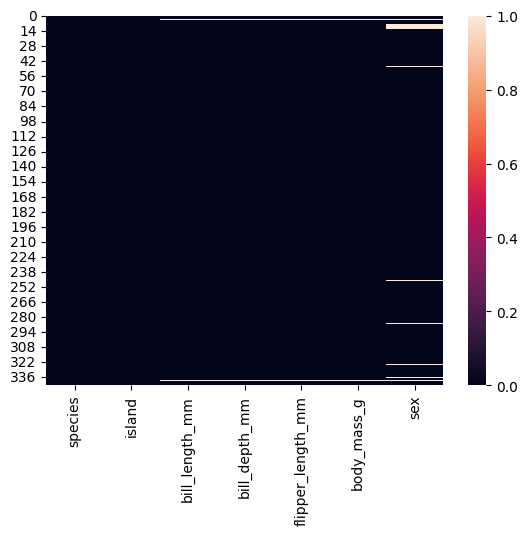

In [7]:
p_df=penguins_df.copy()  #원본 데이터 보호를 위해 복사하여 사용해도 됨

print(p_df.loc[(penguins_df.sex.isna()) |(p_df.bill_length_mm.isna()) |
(p_df.bill_depth_mm.isna())  | (p_df.flipper_length_mm.isna())  |
(p_df.body_mass_g.isna())])

sns.heatmap(p_df.isnull())

###7.dropna() 함수를 이용해 결측치 제거하기로 결정

In [ ]:
p_df = penguins_df.dropna()     #결측치 제거
print(p_df.head(10))

   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0   Adelie  Torgersen            39.1           18.7              181.0   
1   Adelie  Torgersen            39.5           17.4              186.0   
2   Adelie  Torgersen            40.3           18.0              195.0   
4   Adelie  Torgersen            36.7           19.3              193.0   
5   Adelie  Torgersen            39.3           20.6              190.0   
6   Adelie  Torgersen            38.9           17.8              181.0   
7   Adelie  Torgersen            39.2           19.6              195.0   
12  Adelie  Torgersen            41.1           17.6              182.0   
13  Adelie  Torgersen            38.6           21.2              191.0   
14  Adelie  Torgersen            34.6           21.1              198.0   

    body_mass_g     sex  
0        3750.0    Male  
1        3800.0  Female  
2        3250.0  Female  
4        3450.0  Female  
5        3650.0    Male  
6        3625.0  F

###8.중간에 빠진 index 다시 설정

In [8]:
p_df.reset_index(drop =True, inplace =True)  #index 재 설정
print(p_df.head(30))

   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0   Adelie  Torgersen            39.1           18.7              181.0   
1   Adelie  Torgersen            39.5           17.4              186.0   
2   Adelie  Torgersen            40.3           18.0              195.0   
3   Adelie  Torgersen             NaN            NaN                NaN   
4   Adelie  Torgersen            36.7           19.3              193.0   
5   Adelie  Torgersen            39.3           20.6              190.0   
6   Adelie  Torgersen            38.9           17.8              181.0   
7   Adelie  Torgersen            39.2           19.6              195.0   
8   Adelie  Torgersen            34.1           18.1              193.0   
9   Adelie  Torgersen            42.0           20.2              190.0   
10  Adelie  Torgersen            37.8           17.1              186.0   
11  Adelie  Torgersen            37.8           17.3              180.0   
12  Adelie  Torgersen    

###9. describe() 함수를 이용해 평균, 표준편차, 사분위수 등 기본적인 요약 통계량 확인

In [9]:
print(p_df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


###10.  펭귄종류, 서식지(섬), 성별은 범주형이므로 향 후 데이터 분석시 불편하므로 인코딩이 필요하므로 수치형과 범주형 구분해 본다

In [10]:
COL_CAT = ['species', 'island', 'sex']
COL_NUM = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

print(p_df[COL_CAT].nunique(), '\n')
print(p_df[COL_NUM].nunique())


species    3
island     3
sex        2
dtype: int64 

bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
dtype: int64


<Axes: >

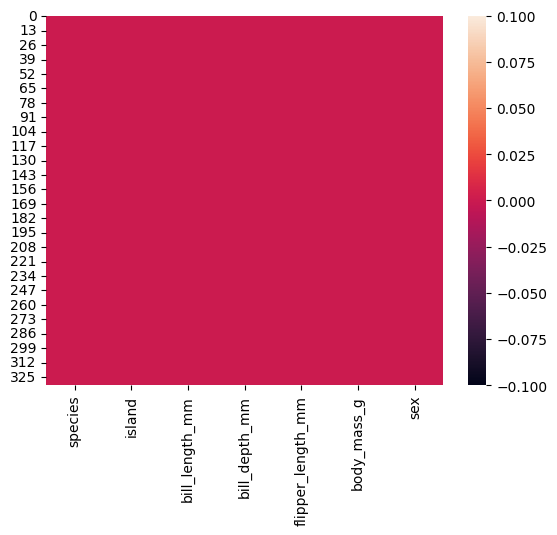

In [ ]:
sns.heatmap(p_df.isnull())

### 11. `flipper_length_mm`과 `body_mass_g`의 상관관계 확인

In [12]:
correlation = p_df['flipper_length_mm'].corr(p_df['body_mass_g'])
print(f"'flipper_length_mm'와 'body_mass_g'의 상관관계: {correlation:.2f}")

'flipper_length_mm'와 'body_mass_g'의 상관관계: 0.87
